#### Understanding Supervised Fine-Tuning
- At its core, supervised fine-tuning is about teaching a pre-trained model to perform specific tasks through examples of labeled tokens. The process involves showing the model many examples of the desired input-output behavior, allowing it to learn the patterns specific to your use case.

> SFT is effective because it uses the foundational knowledge acquired during pre-training while adapting the model's behavior to match your specific needs.

```markdown
#### The following code-snippet takes care of all the data pre-processing and training for you:

```python
from datasets import load_dataset
from trl import SFTConfig, SFTTrainer

dataset = load_dataset("stanfordnlp/imdb", split="train")

training_args = SFTConfig(
    max_length=512,
    output_dir="/tmp",
)
trainer = SFTTrainer(
    "facebook/opt-350m",
    train_dataset=dataset,
    args=training_args,
)
trainer.train()
```

> ake sure to pass the correct value for `max_length` as the default value will be set to `min(tokenizer.model_max_length, 1024)`.

#### You can also construct a model outside of the trainer and pass it as follows:

```python
from transformers import AutoModelForCausalLM
from datasets import load_dataset
from trl import SFTConfig, SFTTrainer

dataset = load_dataset("stanfordnlp/imdb", split="train")

model = AutoModelForCausalLM.from_pretrained("facebook/opt-350m")

training_args = SFTConfig(output_dir="/tmp")

trainer = SFTTrainer(
    model,
    train_dataset=dataset,
    args=training_args,
)

trainer.train()
```

> You can use the `DataCollatorForCompletionOnlyLM` to train your model on the generated prompts only. Note that this works only in the case when `packing=False`. 

To instantiate that collator for `instruction data`, pass a response template and the tokenizer.

> To instantiate that collator for `instruction data`, pass a response template and the tokenizer.
```python
def formatting_prompts_func(example):
    output_texts = []
    for i in range(len(example['instruction'])):
        text = f"### Question: {example['instruction'][i]}\n ### Answer: {example['output'][i]}"
        output_texts.append(text)
    return output_texts

response_template = " ### Answer:"
collator = DataCollatorForCompletionOnlyLM(response_template, tokenizer=tokenizer)
```

> To instantiate that collator for assistant style conversation data, pass a response template, an instruction template and the tokenizer.
```python
dataset = load_dataset("timdettmers/openassistant-guanaco", split="train")

model = AutoModelForCausalLM.from_pretrained("facebook/opt-350m")
tokenizer = AutoTokenizer.from_pretrained("facebook/opt-350m")

instruction_template = "### Human:"
response_template = "### Assistant:"
	collator = DataCollatorForCompletionOnlyLM(	instruction_template=instruction_template, 
	response_template=response_template, 
	tokenizer=tokenizer, mlm=False
)
```

### Why pad_token_id and eos_token_id Matter

In transformer-based language models, tokenization is the process of converting text into a sequence of integers (token IDs) that the model can process. Special tokens like padding (`pad_token_id`) and end-of-sequence (`eos_token_id`) serve distinct purposes:

- **pad_token_id**: Used to pad sequences to a uniform length within a batch. Padding ensures efficient batch processing on GPUs, but these tokens are typically ignored during training via attention masking.
- **eos_token_id**: Marks the end of a meaningful sequence (e.g., a sentence or response). During generation, the model predicts this token to signal that it’s done producing output.

If `pad_token_id` equals `eos_token_id`, the model can confuse padding (a technical necessity) with the end of a sequence (a semantic signal). This confusion disrupts training and generation, especially in tasks like text generation where correctly predicting EOS is essential for coherent outputs.

Some tokenizers like Llama 2 (`meta-llama/Llama-2-XXb-hf`) tokenize sequences differently depending on whether they have context or not. For example:
> response_template **= "### Assistant:"**
```python
print_tokens_with_ids(response_template)  # [('▁###', 835), ('▁Ass', 4007), ('istant', 22137), (':', 29901)]
```

```python
response_template_with_context = "\n### Assistant:"  # We added context here: "\n". This is enough for this tokenizer
response_template_ids = tokenizer.encode(response_template_with_context, add_special_tokens=False)[2:]  
# Now we have it like in the dataset texts: [2277, 29937, 4007, 22137, 29901]
data_collator = DataCollatorForCompletionOnlyLM(response_template_ids, tokenizer=tokenizer)
```

If **pad_token_id** equals **eos_token_id**, the model might:
- Misinterpret padding as a signal to stop generating during training, skewing the loss calculation.
- Fail to predict EOS correctly during inference because it’s been conflated with padding, leading to incomplete or runaway generations (e.g., never stopping or cutting off prematurely).

This issue is particularly pronounced in SFT because the goal is often to align the model with human-like outputs, where EOS prediction is key to natural termination of responses.

**Step 1: Check the Tokenizer**

Load the tokenizer and inspect its special tokens:

```python
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("facebook/opt-350m")
print(f"EOS token ID: {tokenizer.eos_token_id}")  # e.g., 2
print(f"Pad token ID: {tokenizer.pad_token_id}")  # e.g., None or 2
```

If **pad_token_id** is None or matches eos_token_id, you need to set a unique one.

**Step 2: Assign a Unique pad_token_id**

If the tokenizer lacks a padding token, add one (e.g., using an unused token or a new one):

```python
if tokenizer.pad_token_id is None or tokenizer.pad_token_id == tokenizer.eos_token_id:
    tokenizer.pad_token = "[PAD]"  # Define a new token
    tokenizer.pad_token_id = tokenizer.convert_tokens_to_ids("[PAD]")
    # If needed, resize model embeddings to accommodate the new token
    model.resize_token_embeddings(len(tokenizer))
```

**Alternatively, use an existing unused token ID (check the tokenizer’s vocabulary).**

**Step 3: Configure SFTTrainer**

Pass the updated tokenizer to SFTTrainer to ensure consistency:

```python
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset

dataset = load_dataset("imdb", split="train")
sft_config = SFTConfig(max_seq_length=512, output_dir="/tmp")

trainer = SFTTrainer(
    model="facebook/opt-350m",
    tokenizer=tokenizer,  # Updated tokenizer with distinct pad_token_id
    train_dataset=dataset,
    dataset_text_field="text",
    args=sft_config
)
trainer.train()
```

The `tokenizer` argument ensures SFTTrainer uses your modified tokenizer, and the data collator (default or custom) respects the **pad_token_id** for padding.

### Add Special Tokens for Chat Format

Adding special tokens to a language model is crucial for training chat models. These tokens are added between the different roles in a conversation, such as the user, assistant, and system, and help the model recognize the structure and flow of a conversation.

The `setup_chat_format()` function in `trl` easily sets up a model and tokenizer for conversational AI tasks. This function:
- Adds special tokens to the tokenizer, e.g. `<|im_start|>` and `<|im_end|>`, to indicate the start and end of a conversation.
- Resizes the model’s embedding layer to accommodate the new tokens.
- Sets the `chat_template` of the tokenizer, which is used to format the input data into a chat-like format. The default is `chatml` from OpenAI.

**- conversational format**

```json
{"messages": [{"role": "system", "content": "You are helpful"}, {"role": "user", "content": "What's the capital of France?"}, {"role": "assistant", "content": "..."}]}
{"messages": [{"role": "system", "content": "You are helpful"}, {"role": "user", "content": "Who wrote 'Romeo and Juliet'?"}, {"role": "assistant", "content": "..."}]}
{"messages": [{"role": "system", "content": "You are helpful"}, {"role": "user", "content": "How far is the Moon from Earth?"}, {"role": "assistant", "content": "..."}]}
```

**- instruction format**

```json
{"prompt": "<prompt text>", "completion": "<ideal generated text>"}
{"prompt": "<prompt text>", "completion": "<ideal generated text>"}
{"prompt": "<prompt text>", "completion": "<ideal generated text>"}
```

#### Customize your prompts using packed dataset

If your dataset has several fields that you want to combine, for example if the dataset has `question` and `answer` fields and you want to combine them, you can pass a formatting function to the trainer that will take care of that. For example:

```python
def formatting_func(example):
    text = f"### Question: {example['question']}\n ### Answer: {example['answer']}"
    return text

training_args = SFTConfig(packing=True)
trainer = SFTTrainer(
    "facebook/opt-350m",
    train_dataset=dataset,
    args=training_args,
    formatting_func=formatting_func
)

trainer.train()
```
```

### PEFT Finetuning (Parameter Efficient Fine Tuning)

#### What is PEFT Finetuning?
- PEFT Finetuning is a set of techniques designed to **fine-tune machine learning models efficiently**.
- It reduces the number of trainable parameters, enabling **faster and cost-effective model training**.
- Common PEFT techniques include:
  - **Prefix Tuning**
  - **P-tuning**
  - **LoRA (Low-Rank Adaptation)**:
    - Variants like **QLoRA** (Quantized LoRA) and **LongLoRA** have specialized applications.

#### Why Use PEFT Finetuning?

##### **1. Saves Time**
- **Less Trainable Parameters**:
  - Results in shorter training cycles and faster testing of models.
- **Memory Optimization**:
  - Allows training with larger batch sizes and for extended periods, leading to:
    - Lower model loss.
    - Improved performance metrics.

- **Reduced Compute Costs**:
  - Optimized memory usage minimizes the need for high-VRAM instances.
  - Enables training on **larger datasets with smaller VRAM** setups.
- **Efficient Resource Utilization**:
  - Supports enterprises by saving costs without sacrificing performance.

#### Key Applications
- Fine-tuning **Large Language Models (LLMs)**.
- Scenarios where memory and computational efficiency are critical.
- Use cases requiring rapid prototyping and experimentation with datasets or techniques.

### LoRA: Low-Rank Adaptation for Efficient Finetuning

#### **Why Do We Need LoRA?**
- Large language models (**LLMs**) often contain **billions of parameters**, making weight updates during training:
  - **Compute-intensive.**
  - **Memory-demanding.**
- Example:
  - A model with **7B parameters** uses a weight matrix \( W \) of the same size.
  - During backpropagation, updates require a matrix \( \Delta W \), which also has **7B parameters**.
  - Computing \( \Delta W \) can significantly increase **memory and compute costs**.
![](https://substackcdn.com/image/fetch/w_1456,c_limit,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F5dfbd169-eb7e-41e1-a050-556ccd6fb679_1600x672.png)
---

#### **What Does LoRA Do?**
- LoRA introduces **low-rank decomposition** to approximate weight updates:
  - Instead of learning $$  \Delta W $$, it learns two smaller matrices: $$ A $$ and $$ B $$.
  - **Decomposition:** $$  \Delta W = A \cdot B $$, where:
    - \( A \): Small matrix with the same number of rows as \( \Delta W \).
    - \( B \): Small matrix with the same number of columns as \( \Delta W \).

---

#### **How Does LoRA Save Memory?**
- **Example Calculation:**
  - Suppose $$  \Delta W $$  has 10,000 rows and 20,000 columns:
    - Without LoRA: Stores \( 10,000 \times 20,000 = 200,000,000 \) parameters.
    - With LoRA and **rank \( r = 8 \)**:
      - \( A \): \( 10,000 \times 8 \) parameters.
      - \( B \): \( 8 \times 20,000 \) parameters.
      - Total: \( 10,000 \times 8 + 8 \times 20,000 = 240,000 \) parameters.
  - **Reduction Factor:** \( \approx 830\times \) fewer parameters compared to storing \( \Delta W \).

---

#### **Why Does LoRA Work?**
- The original matrix \( W \) needs to be **large** during pretraining to capture all the knowledge from extensive datasets.
- During **finetuning**, only a **subset of the weights** needs to be adjusted.
- **Hypothesis:** These adjustments can be represented in a **low-rank space**, enabling efficient updates via \( A \) and \( B \).

---

#### **Advantages of LoRA**
1. **Memory Efficiency:**
   - Reduces the memory footprint during training.
2. **Cost Effectiveness:**
   - Requires fewer computational resources, making it scalable to larger LLMs.
3. **Flexibility:**
   - Allows for finetuning without impacting the pre-trained weights of the model.

---

LoRA is a practical approach for overcoming the challenges of training LLMs, ensuring efficiency without compromising on performance.

### Observing LoRA Consistency  

#### Key Insight:  -  Across multiple experimental runs, **LoRA's benchmark results remain consistent**, even with:
 -  The inherent randomness of LLM training.
 -  Variability in GPU-based computations.



### QLoRA Finetuning

#### What is QLoRA?
- **QLoRA** stands for **Quantized Low-Rank Adaptation**, a fine-tuning technique.
- Combines **low-precision storage** with **high-precision computation**.
- Keeps model size small while maintaining high performance and accuracy.

---

#### **Key Concepts in QLoRA**
##### 1. **4-bit Normal Float (NF4)**
- A **data type** built on **Quantile Quantization**.
- Steps:
  1. Estimates quantiles in a 0 to 1 distribution.
  2. Normalizes values to the **[-1, 1] range**.
  3. Quantizes neural network weights to these quantiles.
- **Advantage:** Reduces numbers used without significantly impacting performance.

##### 2. **Double Quantization**
- Quantizes the **constants** used in the quantization process itself.
- Achieves additional memory savings (~0.5 bits per parameter).
- Uses **Block-wise k-bit Quantization**:
  - Splits weights into chunks for independent quantization.
  - Generates fewer quantization constants to save space.

##### 3. **Error Reduction with LoRA Tuning**
- **LoRA** (Low-Rank Adaptation) compensates for **quantization errors**:
  - Fine-tunes using **higher precision (BF16 or FP16)** matrices.
  - Forward and backward passes de-quantize weights for high-precision training.
- Reduces quantization inefficiencies during training.

---

#### **How is QLoRA Different from LoRA?**
- Both are fine-tuning techniques, but:
  - **QLoRA** uses **LoRA** to fix quantization errors.
  - **LoRA** operates as a standalone fine-tuning mechanism.

---

#### **Implementation with HuggingFace**
1. Install libraries:
   - **BitsAndBytes** (handles 4-bit quantization).
   - **PEFT** (for LoRA-based fine-tuning).
2. Code Example:
```python
import torch
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

model_id = "EleutherAI/gpt-neox-20b"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

model = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=bnb_config, device_map={"": 0})

model.gradient_checkpointing_enable()
model = prepare_model_for_kbit_training(model)

config = LoraConfig(
    r=8, 
    lora_alpha=32, 
    target_modules=["query_key_value"], 
    lora_dropout=0.05, 
    bias="none", 
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, config)
```

---

#### **Comparison: QLoRA vs Standard Finetuning**
- **QLoRA retains performance**:
  - Maintains the same results as full finetuning (e.g., T5 and LLaMA models).
- **Memory Efficiency**:
  - Uses **4-bit precision**, enabling training larger models with **less VRAM**.
- Example: 
  - **Guanaco** (33B parameters) achieves **99.3% ChatGPT performance** with 4-bit precision, outperforming smaller models like Vicuna (13B).

### **Key Trade-offs**

| **Method**  | **Training Time**  | **Memory Used**  | 
|--------------------------|-------------------|-----------------| 
| Default LoRA (16-bit BF) | 1.85 h | 21.33 GB | 
| QLoRA (4-bit NF) | 2.79 h (+39%) | 14.18 GB (-33%) |

  #### **Observations**
   1.  **Memory Savings**:
 -  QLoRA achieves **33% lower GPU memory usage**, making it ideal for scenarios with limited VRAM. 
 - 2.  **Training Time Increase**:
 -  QLoRA leads to a **39% longer training runtime**  due to extra quantization and dequantization steps.
 -  3.  **Performance Impact**:
 -  Minimal impact on model performance, making it a viable alternative to regular LoRA for addressing GPU memory constraints. 
 
 #### **Conclusion**  
 
> QLoRA offers an efficient balance between compute and memory usage, making it a practical choice when working with hardware limitations.

#### **Advantages of QLoRA**
- **Memory Optimized**:
  - Trains models with high efficiency on systems with limited VRAM.
- **Cost-effective**:
  - Reduces computational expenses without compromising performance.
- **Flexibility**:
  - Suitable for large-scale applications and resource-constrained scenarios.

---

### LongLoRA: Fine-tuning for Longer Context Models

#### **What is LongLoRA?**
- **LongLoRA** is a variation of the **LoRA finetuning technique**, designed to train models capable of handling **longer contexts**.
- It introduces a novel method called **SHIFT SHORT ATTENTION**.

---

#### **How does LongLoRA work?**

##### **Shift Short Attention Mechanism**
- **Process:**
  - Divides tokens into **chunks or groups**.
  - Attention is calculated **independently** within each chunk.
- **Benefits:**
  - Distributes the workload effectively.
  - Enables models to process **longer contexts** without significantly increasing computational complexity.

---

#### **Why use LongLoRA?**
- Handles **extended input sequences**, ideal for tasks requiring contextual information spread over lengthy inputs.
- Optimized for **scaling attention mechanisms**, ensuring memory and compute efficiency.



LongLoRA showcases its value in scenarios where large context windows are critical, **such as legal document analysis, research papers, or any extended discourse.**

### Adam vs SGD Optimizers: Memory Trade-offs in LLM Training

#### **Why Are Adam Optimizers Memory-Intensive?**
- **Adam/AdamW Optimizers** maintain:
  1. **First moment (mean)** of gradients.
  2. **Second moment (uncentered variance)** of gradients.
- This adds **two extra values per model parameter** in memory.
- Example:
  - For a **7B parameter model**, Adam requires **14B additional parameters** to track during training.
#### **SGD Optimizers**
- SGD does **not** track additional parameters during training, making it more memory-efficient by design.

#### **Experiment: Training a 7B Llama 2 Model with LoRA (r=8)**

| **Optimizer** | **GPU Memory Used** | **Observation**                  |
|---------------|----------------------|-----------------------------------|
| **AdamW**     | 14.18 GB            | Minimal difference from SGD.     |
| **SGD**       | 14.15 GB            | Savings of **0.03 GB (~30 MB)**. |

##### **Why Are Savings Minimal?**
- LoRA only trains a **small subset of parameters**:
  - For \( r = 8 \): 
    - Trainable parameters = **4,194,304**.
    - Memory used: **16.78 MB (with optimizer states)**.
- **Overhead** in storing and copying optimizer states contributes to the tiny savings.

---

#### **Experiment: Increasing LoRA Rank (r=256)**

| **Optimizer** | **GPU Memory Used** | **Observation**                            |
|---------------|----------------------|-------------------------------------------|
| **AdamW**     | 17.86 GB            | Significant memory usage increase.         |
| **SGD**       | 14.46 GB            | Noticeable savings: **3.40 GB (~19%)**.   |

---

1. **Small LoRA r (e.g., r=8):**
   - Swapping **Adam for SGD** offers **minimal memory savings**.
2. **Larger LoRA r (e.g., r=256):**
   - SGD becomes a worthwhile alternative for reducing GPU memory requirements.


#### **5. Multiple Training Epochs**
- **Conventional Deep Learning**:
  - Involves multiple passes (epochs) over the training set.
  - Often beneficial for tasks like CNN training.
- **Instruction Finetuning Observations**:
  - Increasing iterations for:
    - **50k Alpaca Dataset**: Performance declined after 2 training epochs.
    - **1k LIMA Dataset**: Similar deterioration noticed.
  - Likely Cause: **Overfitting**, which warrants further investigation.
- **Takeaway**:
  - Multi-epoch training might **not benefit instruction finetuning**, especially with smaller datasets.

#### **6. Enabling LoRA for More Layers**
- **Default Experiment**:
  - LoRA enabled for **Key and Value matrices** in transformer layers.
- **Extended Configuration**:
  - Enabled LoRA for:
    - Query matrices.
    - Projection layers.
    - Other linear layers (between attention blocks and outputs).
- **Results**:
  - Trainable parameters increased **5×**:
    - From **4,194,304** to **20,277,248** (for a 7B Llama 2 model).
  - Memory usage increased:
    - From **14.18 GB** to **16.62 GB**.
  - **Model performance improved noticeably.**


---

#### **7. Balancing LoRA Hyperparameters: R and Alpha**
- **Scaling Formula**:
  $$scaling=α / r$$
  
- **Common Rule of Thumb**:
- Set **alpha = 2 × r**:
  - Example: For **r=8**, choose **alpha=16** (2-fold scaling).

 **Experiment Findings**:
- For **r=256** and **alpha=128** (0.5-fold scaling), performance improved further.
- Larger **r values** (e.g., 256) benefit from adjustments to alpha.
- **Takeaway**:
- While **alpha = 2 × r** often yields good results, experimenting with different ratios can optimize performance for specific setups.


#### How To Avoid Overfitting?

Overfitting occurs when a model performs well on training data but poorly on unseen data. Here are some strategies to mitigate overfitting:

##### Impact of Parameter \(r\)
- Generally, a larger \(r\) can lead to more overfitting because it determines the number of trainable parameters.
- Decreasing \(r\) reduces the model's capacity, which can help to prevent overfitting.
##### Increasing Dataset Size
- If a model suffers from overfitting, increasing the dataset size is one of the first candidates to explore.
- A larger dataset provides more diverse examples, helping the model generalize better.
##### Regularization with Weight Decay
- Optimizers like AdamW or SGD include a weight decay parameter that can act as a regularizer.
- Increasing the weight decay rate penalizes large weights, discouraging complex models that overfit.
##### Dropout in LoRA Layers
- Increasing the dropout value for LoRA layers introduces regularization by randomly deactivating parts of the network during training.
- Experimenting with higher dropout rates than the default (e.g., 0.05) can help improve generalization.




#### Adapters

The adapter method (Houlsby et al.) is somewhat related to prefix tuning, as both approaches add additional parameters to each transformer block. However, their mechanisms differ significantly. Below is an explanation of the adapter method:

##### Key Mechanism
- Instead of prepending prefixes to input embeddings, the adapter method introduces **adapter layers** in two places within each transformer block.



#### Adapter Bottleneck Structure

Adapters utilize a **bottleneck structure**, resembling autoencoders, for parameter efficiency:
![](https://lightningaidev.wpengine.com/wp-content/uploads/2023/04/adapter-outline.png)



#### **Parameter Efficiency of Adapters**

Adapters achieve parameter efficiency through their bottleneck architecture. Let’s delve deeper into this concept:

##### **How Adapters Are Efficient**
- Assume the first fully connected layer projects a **1024-dimensional input** down to **24 dimensions**.
- The second fully connected layer then projects it back to **1024 dimensions**.

##### **Example Calculation**
1. First layer parameters: $$  1024 \times 24 = 24,576 $$
2. Second layer parameters: $$ 24 \times 1024 = 24,576 $$
3. Total parameters: $$ 24,576 + 24,576 = 49,152 $$

In contrast, a single fully connected layer that maps  1024 -dimensional input to itself has:
  1024 times 1024 = 1,048,576   parameters.

This highlights how adapters significantly reduce the number of trainable parameters while maintaining functionality.

#### **Performance Comparison with Prefix Tuning**

When comparing the adapter method with prefix tuning:

##### **Performance Findings**
1. **Prefix Tuning** (as per the original paper):
   - Performed better than adapters when **only 0.1%** of the total model parameters were tuned.
2. **Adapter Tuning**:
   - Matches the performance of prefix tuning when **3%** of model parameters are tuned.

##### **Conclusion**
- **Prefix tuning** is generally more parameter-efficient, achieving comparable or better performance with fewer parameters tuned.
- 


### What is LLaMA-Adapter?

LLaMA-Adapter is a parameter-efficient technique designed to adapt large language models, like LLaMA, for `instruction-following tasks without requiring full retraining`. This method:
- Introduces approximately **1.2 million learnable parameters**, enabling efficient fine-tuning.
- Utilizes adaptation prompts and specialized attention mechanisms to integrate new instructional cues effectively.

---

#### How Does It Work?
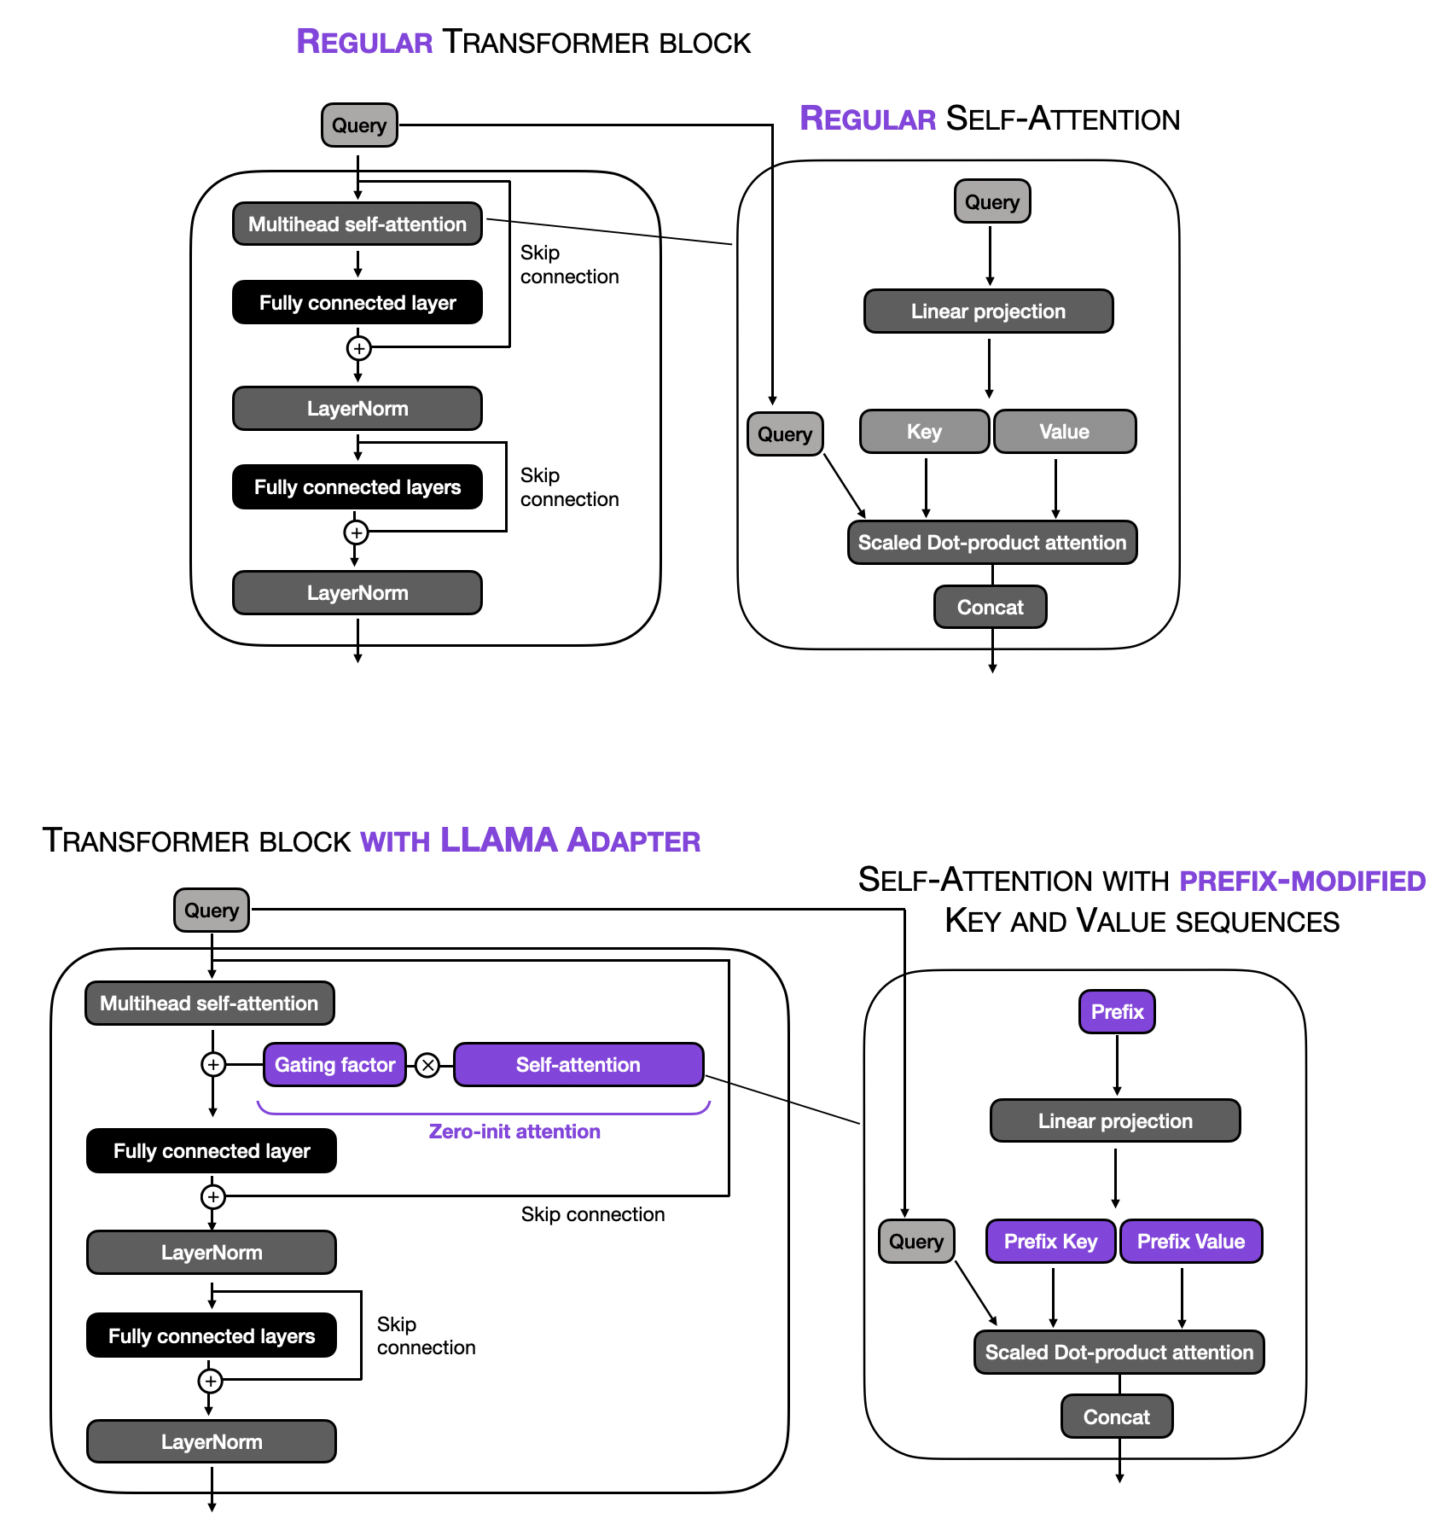
##### Adaptation Prompts
- **Learnable vectors** are added to the input sequence, particularly in higher transformer layers.
- These prompts act like additional tokens, helping the model understand and adapt to specific instructions.

##### Zero-Initialized Attention
- At the start of training, attention weights are set to zero.
- This prevents the disruption of pre-trained knowledge and enables a stable learning process as the model gradually incorporates the prompts.

##### Zero Gating Mechanism
- A control mechanism that begins with **zero influence** from the prompts.
- Gradually opens during training, balancing between learning new information and retaining pre-trained knowledge.
-
For example, in a transformer layer, if the hidden states are `[h1, h2, h3]` for tokens `[token1, token2, token3],` and adaptation prompts are `[p1, p2]`, the input to a higher layer’s self-attention becomes `[p1, p2, h1, h2, h3]`. 

Initially, when computing attention for h1, its query vector `q1 has zero attention to p1 and p2`, but over training, it learns to attend to them as needed.

##### **Selective Layer Modification**: 
- Unlike some methods that modify all transformer layers, LLaMA-Adapter inserts adaptation prompts only into the` topmost layers of the transformer`. 
- ` focuses on higher-level semantic information,` making the fine-tuning process more efficient.


#### Model Comparison: Special Tokens, Chat Generation, and Fine-Tuning Approaches

---

##### **LLaMA**
- **Standard Special Tokens**: `<s>`, `</s>`, `<unk>`, `<pad>`
- **Chat Model Generation**: Text formatting (e.g., "User:", "Assistant:")
- **Instruction Fine-Tuning (SFT/PFT)**: May use `[INST]`, `[/INST]` in some setups.

---

##### **Phi**
- **Standard Special Tokens**: `<s>`, `</s>`, `<unk>`, `<pad>`
- **Chat Model Generation**: Text formatting, no additional tokens.
- **Instruction Fine-Tuning (SFT/PFT)**: May use `[INST]`, `[/INST]` in some setups.

---

##### **Qwen**
- **Standard Special Tokens**: `<s>`, `</s>`, `<unk>`, `<pad>`
- **Chat Model Generation**: Text formatting for roles.
- **Instruction Fine-Tuning (SFT/PFT)**: May use `[INST]`, `[/INST]` in some setups.

---

##### **Mistral**
- **Standard Special Tokens**: `<s>`, `</s>`, `<unk>`, `<pad>`
- **Chat Model Generation**: Text formatting (e.g., "User:", "[response]")
- **Instruction Fine-Tuning (SFT/PFT)**: May use `[INST]`, `[/INST]` in some setups.



### 🔹 Why Don’t Decoder-Only Models Have a `pad_token_id`?

Decoder-only models (e.g., **GPT, LLaMA, Phi-2, Mistral, Qwen**) do not have a default `pad_token_id` because they were designed for **auto-regressive generation**, where padding is not naturally required.

#### Key Reasons:
- **Token-by-Token Generation:**  
  These models generate text one token at a time until an **end condition** (e.g., `eos_token_id`) is met. Padding is unnecessary since output sequences dynamically stop at different lengths.

- **No Attention on Empty Tokens:**  
  Unlike encoder models (e.g., BERT), decoder-only models process variable-length inputs. Padding could interfere with predictions for the next token.

- **Batching Necessity:**  
  Padding is only required for **batch inference** when sequences must be the same length. In these cases, we manually set `pad_token_id` to `eos_token_id` to avoid issues.

---

### 🔹 Why Set `pad_token_id = eos_token_id`?

Manually setting `pad_token_id` to `eos_token_id` helps overcome the lack of a default padding token in decoder-only models. Here's why:

#### Benefits:
- **Avoids Padding Issues in Generation:**  
  Prevents interference with output formatting when tokenizers introduce a separate padding token.  
- **Prevents Unexpected Attention Behavior:**  
  Unique padding tokens can be ignored by attention layers, introducing bias. Using the EOS token ensures consistency.  
- **Compatible with Models Without Native `pad_token_id`:**  
  Many decoder-only models, like LLaMA, lack native support for padding tokens. Setting `pad_token_id = eos_token_id` ensures proper behavior during inference.  

---

### 🔹 Which Models Have a Default `pad_token_id`?

| **Model Type**      | **Example Models**            | **Has Default `pad_token_id`?**                |
|---------------------|------------------------------|-----------------------------------------------|
| **Encoder-Only**    | BERT, RoBERTa, DeBERTa       | ✅ Yes (needed for masked attention)          |
| **Encoder-Decoder** | T5, BART, mT5, Pegasus       | ✅ Yes (for sequence-to-sequence tasks)       |
| **Decoder-Only**    | GPT-2, GPT-3, LLaMA, Phi-2, Mistral, Qwen | ❌ No (must set manually for batching) |

---

### 🔹 How to Set `pad_token_id` for Decoder-Only Models

To avoid errors during batch inference or fine-tuning for tasks requiring consistent sequence lengths, use this approach:

```python
# Assign PAD as EOS
tokenizer.pad_token = tokenizer.eos_token

# Ensure the model recognizes PAD
model.config.pad_token_id = tokenizer.pad_token_id
```

---

### 🔹 When to Use `pad_token_id = eos_token_id`

#### ✅ Use Cases:
- Fine-tuning and inference for **open-ended generation** (e.g., chat, storytelling).  
- Working with **decoder-only models** that lack a dedicated `pad_token_id`.  
- Batch inference where sequences require consistent padding.  

#### 🚫 Avoid When:
- Your model has a distinct `pad_token_id` required for structured tasks like summarization or classification.




| Algorithm | Description | Update Rule | Advantages | Disadvantages |
|-----------|-------------|-------------|------------|---------------|
| **Stochastic Gradient Descent (SGD)** | Updates parameters using the gradient of the loss function with respect to each parameter. | $$ \theta = \theta - \eta \cdot \nabla J(\theta) $$ | Simple and effective for convex problems. | Can be slow to converge and sensitive to the choice of learning rate. |
| **SGD with Momentum** | Accelerates SGD by adding a fraction of the previous update to the current update, helping to navigate along relevant directions and dampen oscillations. | $$ v_t = \gamma v_{t-1} + \eta \nabla J(\theta) $$ $$ \theta = \theta - v_t $$ | Faster convergence and helps in escaping local minima. | Requires tuning of the momentum term \( \gamma \). |
| **Nesterov Accelerated Gradient (NAG)** | Improves upon momentum by calculating the gradient at the anticipated next position, leading to more accurate updates. | $$ v_t = \gamma v_{t-1} + \eta \nabla J(\theta - \gamma v_{t-1}) $$ $$ \theta = \theta - v_t $$ | Provides a form of lookahead, leading to faster convergence. | More complex to implement and understand. |
| **Adagrad** | Adapts the learning rate for each parameter based on the historical gradients, making it suitable for sparse data. | $$ \theta = \theta - \frac{\eta}{\sqrt{G_{t,ii} + \epsilon}} \nabla J(\theta) $$ where \( G_t \) is the diagonal matrix of past squared gradients. | Automatically adjusts learning rates, beneficial for sparse data. | `The problem with AdaGrad is that the learning rate constantly decays` , Learning rate can become very small over time, leading to slow convergence. |
| **Adadelta** | An extension of Adagrad that seeks to reduce its aggressive, monotonically decreasing learning rate by using a moving window of gradient updates. | $$ E[g^2]_t = \rho E[g^2]_{t-1} + (1 - \rho) \nabla J(\theta)^2 $$ $$ \Delta \theta = - \frac{\sqrt{E[\Delta \theta^2]_{t-1} + \epsilon}}{\sqrt{E[g^2]_t + \epsilon}} \nabla J(\theta) $$ $$ E[\Delta \theta^2]_t = \rho E[\Delta \theta^2]_{t-1} + (1 - \rho) (\Delta \theta)^2 $$ | Eliminates the need for a manually selected global learning rate. | Introduces additional moving averages and computations, increasing complexity. |
| **RMSprop** | The problem with AdaGrad is that the learning rate constantly decays. This can cause the learning rate to decrease excessively before many tasks reach the optimal solution. Therefore, RMSprop uses exponential moving average to slowly discard previous gradient history. This prevents the learning rate from decreasing too early. | $$ E[g^2]_t = \rho E[g^2]_{t-1} + (1 - \rho) \nabla J(\theta)^2 $$ $$ \theta = \theta - \frac{\eta}{\sqrt{E[g^2]_t + \epsilon}} \nabla J(\theta) $$ | Adaptive learning rates and prevents very small updates. | Can be sensitive to the choice of hyperparameters. |
| **Adam** | Combines the benefits of both RMSprop and momentum by computing adaptive learning rates for each parameter, considering both the first moment (mean) and the second moment (uncentered variance) of the gradients. ` It takes into account the first-order moment estimation (mean of the gradients) and the second-order moment estimation (uncentered variance of the gradients) to calculate the update step`. | $$ m_t = \beta_1 m_{t-1} + (1 - \beta_1) \nabla J(\theta) $$ $$ v_t = \beta_2 v_{t-1} + (1 - \beta_2) (\nabla J(\theta))^2 $$ $$ \hat{m}_t = \frac{m_t}{1 - \beta_1^t} $$ $$ \hat{v}_t = \frac{v_t}{1 - \beta_2^t} $$ $$ \theta = \theta - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t $$ | -> `Lower memoery requirement` Generally performs well across a wide range of problems and requires less tuning of the learning rate. --- Very suitable for scenarios with large-scale data and parameters, unstable objective functions, and problems with sparse gradients or significant gradient noise.  | Can be sensitive to the choice of hyperparameters and may not always converge to the optimal solution. |


> `Adafactor` and `SGD` use `four bytes` of memory per parameter, while `AdamW` uses `eight` bytes per parameter. 

- This means that a 7B model undergoing full fine-tuning with the   `AdamW optimizer requires 7 * 8 = ~56GB` of memory to store the optimizer states alone. `Even more memory is` needed to store the parameters, gradients, and the forward activations.
> `adamw_bnb_8bit`
> A 7B model undergoing full fine-tuning with the AdamW 8-bit version requires only ~14GB of memory for the optimizer state.


- \( \theta \): Model parameters  
- \( \eta \): Learning rate  
- \( \nabla J(\theta) \): Gradient of the loss function with respect to \( \theta \)  
- \( v_t \): Velocity term in momentum-based methods  
- \( \gamma \): Momentum coefficient  
- \( G_t \): Accumulated sum of squares of past gradients  
- \( \epsilon \): Small constant to prevent division by zero  
- \( \rho \): Decay rate for moving averages  
- \( m_t, v_t \): Estimates of the first and second moments of the gradients in Adam  
- \( \beta_1, \beta_2 \): Exponential decay rates for the moment estimates in Adam  


This table provides a concise overview of each optimization algorithm's mechanism, benefits, and potential drawbacks, aiding in the selection of the most appropriate optimizer for a given machine learning task. 

### **Optimizers in Hugging Face: Understanding 8-bit AdamW, Paged Optimizers, and Alternatives**  

#### **1. 8-bit AdamW vs. Standard AdamW**  
- **Benchmark Results:** Stas Bekman’s tests show that **8-bit AdamW** is actually **faster** than the standard **AdamW** optimizer.  
- **Why is this surprising?** Normally, reducing precision (from 32-bit to 8-bit) can slow down optimization due to quantization effects, but in this case, the reduced memory usage improves overall efficiency.  
- **Comparison with Adafactor:** Adafactor, another memory-efficient optimizer, is **slightly slower** than AdamW.  

---

#### **2. Default Optimizer in Hugging Face: AdamW**  
- **AdamW is the default optimizer** in the Hugging Face `TrainingArguments` class.  
- **It works well in most cases**, but if it does not, you can try:  
  - **Adafactor:** A more memory-efficient alternative, often used for large transformer models.  
  - **Lion:** A newer optimizer designed for both efficiency and performance.  
  - **SGD (Stochastic Gradient Descent):** Works well for reinforcement learning tasks.  

---

#### **3. Why Use 8-bit AdamW?**  
- **Memory Constraints:** Training large models requires significant GPU memory, and AdamW normally uses **8 bytes per parameter**.  
- **8-bit AdamW reduces memory usage,** allowing larger models to be trained on the same hardware.  
- **It is also faster,** making it an attractive alternative to standard AdamW.  

---

#### **4. Paged Optimizers: Handling Memory Limits**  
- **Problem:** When fine-tuning large models, GPU memory can run out, limiting sequence length or batch size.  
- **Solution:** **Paged optimizers** help by **automatically offloading memory to CPU RAM** when needed.  
  - This allows models to **train beyond GPU memory limits** without crashing.  
  - When the optimizer needs data, it **transfers it back to the GPU dynamically.**  

---

#### **5. Paged Optimizers in Hugging Face**  
Hugging Face provides **paged variants** of AdamW and Lion, which further optimize memory usage.  

> Using AdamW as an optimizer requires eight bytes of memory per parameter, which is a significant drag on memory requirements. This affects the maximum sequence length that can be supported. 

- **Paged AdamW:**  
  - `paged_adamw_32bit`  
  - `paged_adamw_8bit`  
- **Paged Lion:**  
  - `paged_lion`  
  - `paged_lion_8bit`  

These optimizers **help maximize efficiency** when working with large models or limited GPU resources.  

---

### **Conclusion**  
- **8-bit AdamW is a strong alternative** to standard AdamW, offering better speed and lower memory usage.  
- **Paged optimizers allow training on larger models** by managing memory between GPU and CPU.  
- **For best performance:** If memory is a concern, use **8-bit AdamW + paged optimizers** to **train bigger models efficiently.**

### **Memory Optimization Parameters in Deep Learning**  

When training deep learning models, memory and compute optimizations are crucial, especially for **large models** that struggle with GPU limitations. Two widely used techniques to **optimize memory usage** while managing compute overhead are **Gradient Checkpointing** and **Gradient Accumulation**.  

---

## **1. Gradient Checkpointing**  
### **Concept**  
- **Saves memory** by recomputing activations during backpropagation instead of storing them.  
- **Trade-off:** Reduces memory usage **but increases compute time**.  

### **How It Works**  
1. In **standard backpropagation**, all activations from the forward pass are **stored in memory** for use in the backward pass.  
2. With **gradient checkpointing**, **only selected activations** are stored.  
3. **During backpropagation,** the missing activations are **recomputed on the fly** instead of being retrieved from memory.  

### **Why Use It?**  
✅ **Allows training larger models** when GPU memory is limited.  
✅ **Enables training even when batch size = 1 does not fit in GPU memory.**  
⚠️ **More compute required** due to repeated calculations.  

For deeper technical insights, **Yaroslav Bulatov’s blog** explains this in more detail.  

---

## **2. Gradient Accumulation**  
### **Concept**  
- Helps simulate a **larger batch size** without requiring more GPU memory.  
- **Trade-off:** Training is slower, but memory usage is reduced.  

### **How It Works**  
1. Instead of updating weights **after every batch**, we **accumulate gradients** over multiple small batches.  
2. After a set number of batches, the gradients are **summed or averaged** before updating the model.  
3. This allows models to **train with an effective larger batch size** while using only small batches that fit in memory.  

### **Why Use It?**  
✅ **Overcomes memory constraints** for large batch sizes.  
✅ **Retains the benefits of larger batch training** (e.g., better stability).  
⚠️ **Does not reduce compute requirements**—total computation remains the same.  
⚠️ **Training becomes slower** due to fewer updates per epoch.  

---

### **Final Thoughts**  
| Technique | Memory Savings | Compute Cost | Best Use Case |
|-----------|---------------|--------------|--------------|
| **Gradient Checkpointing** | ✅ High | ❌ Higher compute | Large models with extreme memory constraints |
| **Gradient Accumulation** | ✅ Moderate | ⚠️ No compute savings, slower training | When batch size is memory-limited |

Both techniques are useful depending on whether **memory** or **training speed** is the main bottleneck.

### REF:

- https://lightning.ai/pages/community/article/understanding-llama-adapters/#adapters
- https://github.com/rasbt/blog-finetuning-llama-adapters/tree/main
- https://medium.com/@florian_algo/optimization-algorithm-from-sgd-to-adam-50ea22187951